In [6]:
from google.colab import files
uploaded = files.upload()

Saving raw_data.csv to raw_data (2).csv


In [7]:
import pandas as pd

df = pd.read_csv('raw_data.csv')

df.head()

,Age,Sleep_Hours,Screen_Time,Work_Hours,Exercise_Hours,Productivity_Score
0,22,7,5,6,1.0,78
1,25,6,8,7,0.5,65
2,19,8,4,5,1.5,85
3,28,5,9,8,0.0,60
4,23,7,6,6,1.0,75


In [8]:
import pandas as pd

# load data
df = pd.read_csv('raw_data.csv')

# check data
print("First 5 rows:")
print(df.head())

print("\nInfo:")
print(df.info())

# remove missing values (if any)
df = df.dropna()

# create new column (IMPORTANT 🔥)
df['Efficiency'] = df['Productivity_Score'] / df['Work_Hours']

# create category for sleep
df['Sleep_Category'] = pd.cut(df['Sleep_Hours'],
                             bins=[0,5,7,10],
                             labels=['Low Sleep','Moderate Sleep','Good Sleep'])

# save cleaned data
df.to_csv('cleaned_data.csv', index=False)

print("\n✅ Data cleaned and new features added!")

First 5 rows:
   Age  Sleep_Hours  Screen_Time  Work_Hours  Exercise_Hours  \
0   22            7            5           6             1.0   
1   25            6            8           7             0.5   
2   19            8            4           5             1.5   
3   28            5            9           8             0.0   
4   23            7            6           6             1.0   

   Productivity_Score  
0                  78  
1                  65  
2                  85  
3                  60  
4                  75  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 50 non-null     int64  
 1   Sleep_Hours         50 non-null     int64  
 2   Screen_Time         50 non-null     int64  
 3   Work_Hours          50 non-null     int64  
 4   Exercise_Hours      50 non-null     float64
 5   

In [9]:
# average productivity
print("Average Productivity:", df['Productivity_Score'].mean())

# sleep vs productivity
print("\nSleep vs Productivity:")
print(df.groupby('Sleep_Category')['Productivity_Score'].mean())

# screen time vs productivity
print("\nScreen Time vs Productivity:")
print(df.groupby('Screen_Time')['Productivity_Score'].mean().head())

# correlation
print("\nCorrelation:")
print(df.corr(numeric_only=True))

Average Productivity: 71.42

Sleep vs Productivity:
Sleep_Category
Low Sleep         57.333333
Moderate Sleep    70.538462
Good Sleep        87.416667
Name: Productivity_Score, dtype: float64

Screen Time vs Productivity:
Screen_Time
3    88.666667
4    86.166667
5    75.500000
6    74.428571
7    67.142857
Name: Productivity_Score, dtype: float64

Correlation:
                         Age  Sleep_Hours  Screen_Time  Work_Hours  \
Age                 1.000000    -0.906088     0.875326    0.910056   
Sleep_Hours        -0.906088     1.000000    -0.974260   -0.933613   
Screen_Time         0.875326    -0.974260     1.000000    0.898798   
Work_Hours          0.910056    -0.933613     0.898798    1.000000   
Exercise_Hours     -0.901987     0.979543    -0.963101   -0.928197   
Productivity_Score -0.895422     0.982445    -0.977153   -0.938798   
Efficiency         -0.911219     0.949701    -0.932722   -0.967415   

                    Exercise_Hours  Productivity_Score  Efficiency  
Age   

/tmp/ipykernel_1802/1125826755.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Sleep_Category')['Productivity_Score'].mean())


/tmp/ipykernel_1802/3820156205.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Sleep_Category')['Productivity_Score'].mean().plot(kind='bar')


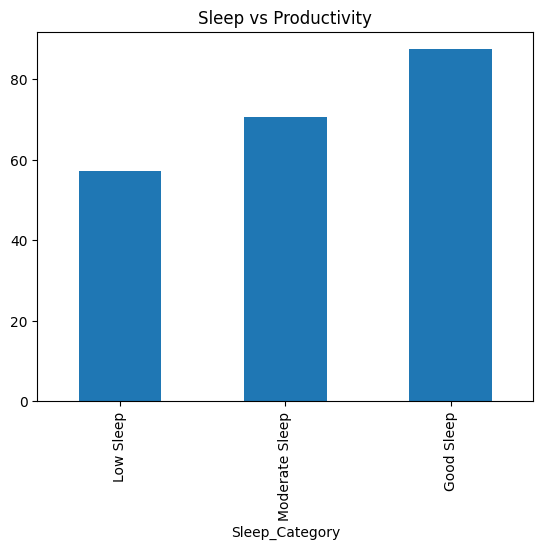

In [10]:
import matplotlib.pyplot as plt

# sleep vs productivity
df.groupby('Sleep_Category')['Productivity_Score'].mean().plot(kind='bar')
plt.title("Sleep vs Productivity")
plt.show()

In [11]:
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>